# SciPy Bootcamp — W2, Day D3C
```
##### Sample size, power curves, peeking, experiment design
##### NormalIndPower, TTestIndPower, sequential testing
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — Sample size calculator with power curves
##### Q2 — Peeking problem demonstration
##### Q3 — Runtime planning
##### Q4 — Type I vs Type II trade-off
##### Q5 — Full experiment design


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Sample size calculator with power curves

```
# Build sample_size_calculator(baseline, mde, alpha=0.05, power=0.80) for proportions.
# (a) For baseline=0.065, MDE values [0.005, 0.01, 0.015, 0.02, 0.03]:
#     Plot required n vs MDE. Annotate each point with the n value.
# (b) For baseline=0.065, MDE=0.015: plot power curve (n=500 to 8000).
#     Mark 80% power threshold. Mark 90% power threshold.
# (c) How many more users do you need to go from 80% to 90% power?
#     Annotate this on the chart.
```


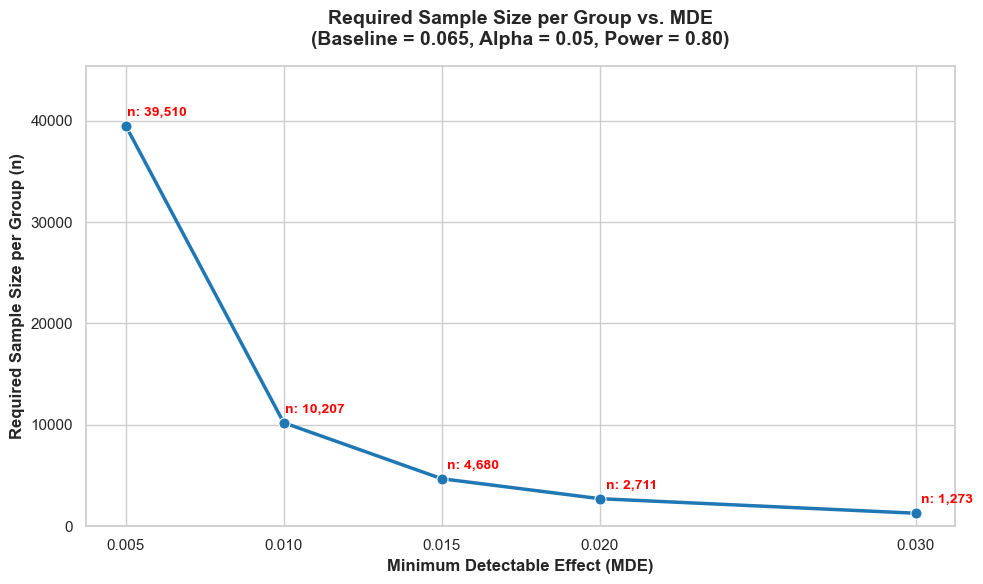

In [33]:
# (a) For baseline=0.065, MDE values [0.005, 0.01, 0.015, 0.02, 0.03]:
#     Plot required n vs MDE. Annotate each point with the n value.

baseline    = 0.065
mde         = [0.005, 0.01, 0.015, 0.02, 0.03]
alpha       = 0.05 
power       = 0.80

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

n_per_group = []

for m in mde:
    effect_size = proportion_effectsize(baseline + m, baseline)
    n = NormalIndPower().solve_power(effect_size=effect_size,
                                        alpha=alpha,
                                        power=power,
                                        alternative='two-sided'
                                            )
    n_per_group.append(int(np.ceil(n)))


# plotting
plt.figure(figsize=(10,6))
sns.lineplot(x=mde, y=n_per_group, color='#1f77b4', marker='o', markersize=8, linewidth=2.5)

# add annotate
for i, txt in enumerate(n_per_group):
    plt.annotate(f'n: {txt:,}', xy=(mde[i], n_per_group[i]), xytext=(mde[i]+0.001, n_per_group[i]+1000), ha='center', fontsize=10, weight='bold', color='red')

plt.title(f'Required Sample Size per Group vs. MDE\n(Baseline = {baseline}, Alpha = 0.05, Power = 0.80)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Minimum Detectable Effect (MDE)', fontsize=12, fontweight='bold')
plt.ylabel('Required Sample Size per Group (n)', fontsize=12, fontweight='bold')
plt.xticks(mde)
plt.ylim(0, max(n_per_group) * 1.15)  # Add padding above highest point for labels

plt.tight_layout()
plt.show()

Additional users for 90% vs 80% power: 1,585 per group


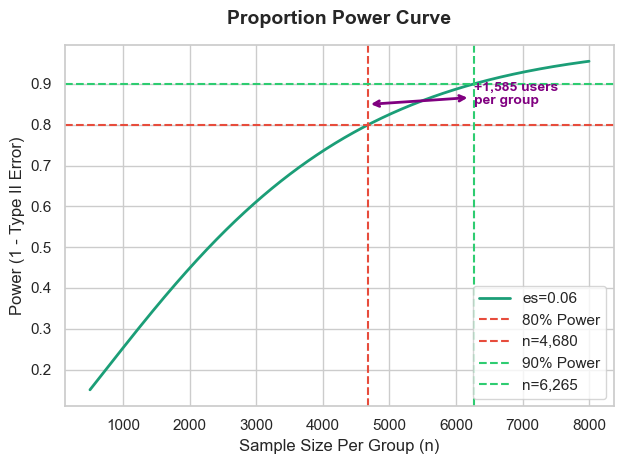

In [108]:
# (b) For baseline=0.065, MDE=0.015: plot power curve (n=500 to 8000).
#     Mark 80% power threshold. Mark 90% power threshold.


baseline    = 0.065            
mde         = 0.015              
alpha       = 0.05 
power       = [0.80, 0.90]

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect_size = proportion_effectsize(baseline + mde, baseline)

n_per_group = []

for p in power:
    n = NormalIndPower().solve_power(effect_size=effect_size,
                                        alpha=alpha,
                                        power=p,
                                        alternative='two-sided'
                                            )
    n_per_group.append(int(np.ceil(n)))

print(f"Additional users for 90% vs 80% power: {n_per_group[1]-n_per_group[0]:,} per group")

# plotting

sample_sizes = np.linspace(500,8000,5000)
NormalIndPower().plot_power(nobs=sample_sizes, effect_size=[effect_size], alpha=0.05, alternative='two-sided')
colors = ['#e74c3c', '#2ecc71']

for i, n in enumerate(n_per_group):
    plt.axhline(power[i], color=colors[i], linestyle='--', label=f'{int(power[i]*100)}% Power')
    plt.axvline(n_per_group[i], color=colors[i], linestyle='--', label=f'n={int(np.ceil(n_per_group[i])):,}')


plt.annotate(f"+{n_per_group[1]-n_per_group[0]:,} users\nper group", xy=(n_per_group[0], 0.85), xytext=(n_per_group[1], 0.85), arrowprops=dict(arrowstyle="<->", color="purple", lw=2), fontsize=10, weight='bold', color='purple')

plt.title("Proportion Power Curve", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Sample Size Per Group (n)", fontsize=12)
plt.ylabel("Power (1 - Type II Error)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

---

### Q2 — Peeking problem demonstration

```
# Simulate 1000 experiments, H0 true, 1000 users per day, 14 days.
# (a) Plot: x=day, y=cumulative false positive rate (peeking vs fixed horizon).
#     Use two lines — show how peeking rate grows over time.
# (b) At what day does peeking false positive rate exceed 15%?
# (c) Simulate the same with a TRUE effect (+1.5pp). Plot power vs day for both approaches.
# (d) Write a comment: what is the business cost of a 20% false positive rate in A/B testing?
```


In [56]:
# Simulate 1000 experiments, H0 true, 1000 users per day, 14 days.
# (a) Plot: x=day, y=cumulative false positive rate (peeking vs fixed horizon).
#     Use two lines — show how peeking rate grows over time.

np.random.seed(420)
n_experiments = 1000
daily_n       = 1000
days          = 14
alpha         = 0.05

false_positive_peeking  = 0
false_positive_fixed    = 0

for _ in range(n_experiments):
    ctrl_all = np.random.binomial(1, 0.10, daily_n * days)
    trt_all  = np.random.binomial(1, 0.10, daily_n * days)  # same rate!
    
    # Peeking: check every day, stop if significant
    peeked_significant = False
    for d in range(1, days + 1):
        c = ctrl_all[:d * daily_n]
        t = trt_all[:d * daily_n]
        _, p = stats.ttest_ind(c, t)
        if p < alpha:
            peeked_significant = True
            break
    if peeked_significant:
        false_positive_peeking += 1
    
    # Fixed horizon: only look at the end
    _, p_final = stats.ttest_ind(ctrl_all, trt_all)
    if p_final < alpha:
        false_positive_fixed += 1

print(f'False positive rate with peeking:      {false_positive_peeking/n_experiments:.1%}')
print(f'False positive rate with fixed horizon: {false_positive_fixed/n_experiments:.1%}')
print(f'Expected (alpha=0.05):                  5.0%')
print()
print('Peeking can inflate false positives to over 20% — 4-5x the nominal rate.')


False positive rate with peeking:      20.7%
False positive rate with fixed horizon: 3.4%
Expected (alpha=0.05):                  5.0%

Peeking can inflate false positives to over 20% — 4-5x the nominal rate.


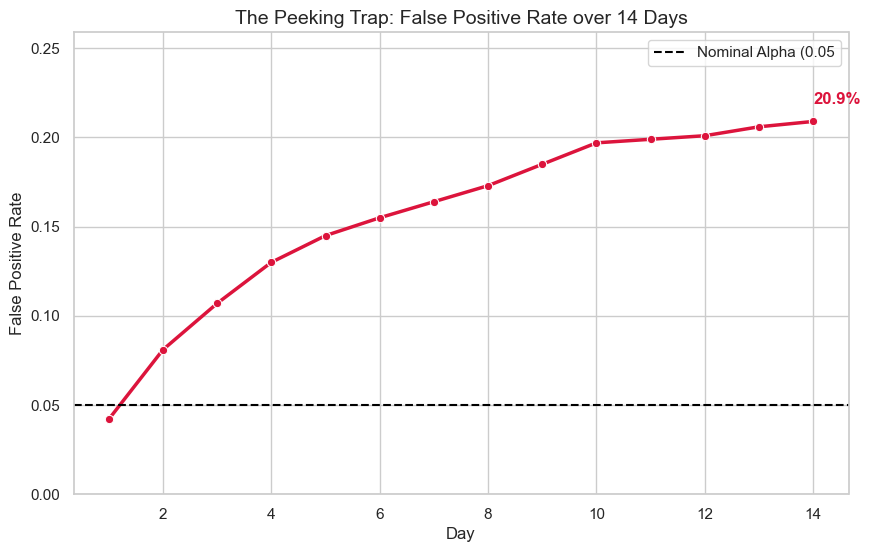

In [57]:
first_sig_day = []

for _ in range(n_experiments):
    ctrl_all = np.random.binomial(1, 0.10, daily_n * days)
    trt_all  = np.random.binomial(1, 0.10, daily_n * days)
    
    day_it_hit = None
    for d in range(1, days + 1):
        c = ctrl_all[:d * daily_n]
        t = trt_all[:d * daily_n]
        _, p = stats.ttest_ind(c, t)
        if p < alpha:
            day_it_hit = d
            break
    first_sig_day.append(day_it_hit)

daily_counts = [sum(1 for day in first_sig_day if day is not None and day <= d) for d in range(1, days + 1)]
cumulative_fp_rate = [count / n_experiments for count in daily_counts]

df_plot = pd.DataFrame({
    'Day': range(1, days + 1),
    'False Positive Rate': cumulative_fp_rate
})

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df_plot, x='Day', y='False Positive Rate', marker='o', color='crimson', linewidth=2.5)

plt.axhline(alpha, color='black', linestyle='--', label=f'Nominal Alpha ({alpha}')

final_rate = cumulative_fp_rate[-1]
plt.text(days, final_rate + 0.01, f'{final_rate:.1%}', weight='bold', color='crimson')

plt.title(f"The Peeking Trap: False Positive Rate over {days} Days", fontsize=14)
plt.ylim(0, max(cumulative_fp_rate) + 0.05)
plt.legend()
plt.show()

In [62]:
# (b) At what day does peeking false positive rate exceed 15%? on the 6th day of the test
df_plot[df_plot['False Positive Rate'] > 0.15]['Day'].min()

6

In [64]:
# (c) Simulate the same with a TRUE effect (+1.5pp). Plot power vs day for both approaches.

np.random.seed(420)
n_experiments = 1000
daily_n       = 1000
days          = 14
alpha         = 0.05

power_peeking  = 0
power_fixed    = 0

for _ in range(n_experiments):
    ctrl_all = np.random.binomial(1, 0.10, daily_n * days)
    trt_all  = np.random.binomial(1, 0.115, daily_n * days)  # TRUE effect (+1.5pp)
    
    # Peeking: check every day, stop if significant
    peeked_significant = False
    for d in range(1, days + 1):
        c = ctrl_all[:d * daily_n]
        t = trt_all[:d * daily_n]
        _, p = stats.ttest_ind(c, t)
        if p < alpha:
            peeked_significant = True
            break
    if peeked_significant:
        power_peeking += 1
    
    # Fixed horizon: only look at the end
    _, p_final = stats.ttest_ind(ctrl_all, trt_all)
    if p_final < alpha:
        power_fixed += 1

print(f'Statistical Power with peeking:      {power_peeking/n_experiments:.1%}')
print(f'Statistical Power with fixed horizon: {power_fixed/n_experiments:.1%}')
print(f'Expected (alpha=0.05):                  5.0%')
print()
print('Note: Peeking artificially inflates power here because it over-rejects the null')



Statistical Power with peeking:      99.0%
Statistical Power with fixed horizon: 97.7%
Expected (alpha=0.05):                  5.0%

Note: Peeking artificially inflates power here because it over-rejects the null


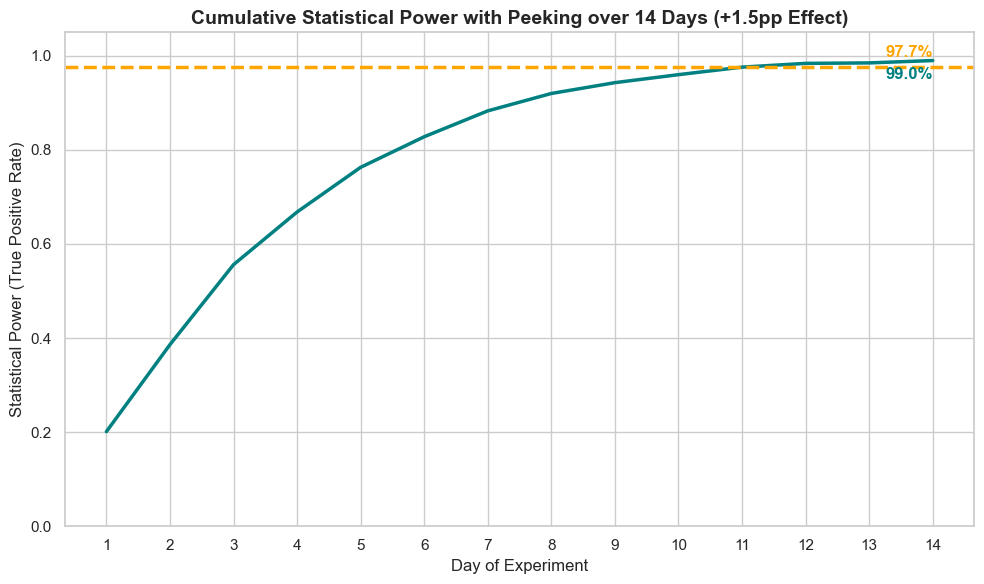

In [72]:
np.random.seed(420)
first_sig_day = []
power_fixed = 0

# Simulate 1000 experiments with a TRUE effect (+1.5pp)
for _ in range(n_experiments):
    ctrl_all = np.random.binomial(1, 0.10, daily_n * days)
    trt_all  = np.random.binomial(1, 0.115, daily_n * days)  # <-- True Effect (+1.5pp)
    
    day_it_hit = None
    for d in range(1, days + 1):
        c = ctrl_all[:d * daily_n]
        t = trt_all[:d * daily_n]
        _, p = stats.ttest_ind(c, t)
        if p < alpha:
            day_it_hit = d
            break
    first_sig_day.append(day_it_hit)

    _, p_final = stats.ttest_ind(ctrl_all, trt_all)
    if p_final < alpha:
        power_fixed += 1


# Calculate cumulative counts over time for power
daily_counts = [sum(1 for day in first_sig_day if day is not None and day <= d) for d in range(1, days + 1)]
cumulative_power = [count / n_experiments for count in daily_counts]
fixed_power_value = power_fixed / n_experiments 


# Map results to a Pandas DataFrame for Seaborn compatibility
df_plot = pd.DataFrame({
    'Day': list(range(1, days + 1)),
    'Statistical Power': cumulative_power
})

# Initialize the plot layout
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot using Seaborn lineplot syntax
sns.lineplot(data=df_plot, x='Day', y='Statistical Power',  
             markers='o', color='teal', linewidth=2.5)

# Add data value anchor point on the final day
final_power = cumulative_power[-1]


# Add fixed power line
plt.axhline(fixed_power_value, color='orange', linestyle='--', linewidth=2.5, 
            label=f'Fixed Horizon Target ({fixed_power_value:.1%})')

# Formatting and Titles
final_power = cumulative_power[-1]
plt.text(days, final_power - 0.04, f'{final_power:.1%}', weight='bold', color='teal', ha='right')
plt.text(days, fixed_power_value + 0.02, f'{fixed_power_value:.1%}', weight='bold', color='orange', ha='right')

plt.title(f"Cumulative Statistical Power with Peeking over {days} Days (+1.5pp Effect)", fontsize=14, fontweight='bold')
plt.xlabel("Day of Experiment")
plt.ylabel("Statistical Power (True Positive Rate)")
plt.xticks(list(range(1, days + 1)))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

````
(d) Write a comment: what is the business cost of a 20% false positive rate in A/B testing?

A 20% FPR means 1 out of 5 "winning" features is a statistical illusion.
This causes four critical forms of business drag:

1. PRODUCT CLUTTER & METRIC DRIFT
   - Deploys phantom wins that add no value.
   - Causes codebloat, complex maintenance, and slower application performance.
   - Core macro metrics (revenue/retention) flatline despite reported team wins.

2. ENGINEERING RESOURCE WASTAGE
   - If deploying an A/B winner costs $50,000 in sprint resources:
   - Out of 50 assumed winners, 10 are actually false positives.
   - Directly burns $500,000 on dead features.

3. OPPORTUNITY COST
   - Engineering hours spent scaling fake wins are permanently lost.
   - diverts resources from building real, high-impact growth features.

4. LOSS OF DATA TRUST
   - When macro metrics lag behind team win reports, leadership loses faith.
   - Culture shifts from data-driven back to intuition and HiPPO decisions.

---

### Q3 — Runtime planning

```
# A new feature will be tested on a health platform.
# Baseline conversion: 7.2%. MDE: 1.5pp. Alpha: 0.05. Power: 0.80.
# Daily visitors: 18,000. Traffic allocation: 50%.
# (a) Calculate required n per group.
# (b) Simulate 8 weeks of daily traffic with weekly seasonality
#     (Mon-Fri +15% above avg, weekends -30%).
# (c) Plot: x=calendar day, y=cumulative users in experiment.
#     Mark the day required n is reached with a vertical line.
# (d) Why should you NOT stop the experiment on that exact day?
```


In [74]:
# (a) Calculate required n per group.

baseline    = 0.072        
mde         = 0.015        
alpha       = 0.05 
power       = 0.80

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
effect_size = proportion_effectsize(baseline + mde, baseline)
n_per_group = NormalIndPower().solve_power(effect_size=effect_size,
                                        alpha=alpha,
                                        power=power,
                                        alternative='two-sided'
                                            )
print(f'Required n per group (proportions): {int(np.ceil(n_per_group)):,}')

Required n per group (proportions): 5,095


In [76]:
# (d) Simulate 8 weeks of daily traffic with weekly seasonality
#     (Mon-Fri +15% above avg, weekends -30%)

required_n = n_per_group
avg_daily_experiment_traffic = 18000 * 0.50  # 50% allocation = 9,000 total users/day
weeks = 8
total_days = weeks * 7

# Generate seasonal traffic variation (Assume Day 1 is Monday)
daily_users = []
for day in range(total_days):
    weekday = day % 7  # 0 to 4 are Mon-Fri, 5-6 are Sat-Sun
    if weekday < 5:
        traffic = avg_daily_experiment_traffic * 1.15   # Weekday surge
    else:
        traffic = avg_daily_experiment_traffic * 0.70   # Weekend drop
    daily_users.append(int(traffic))

# Accumulate users
cumulative_users = np.cumsum(daily_users)

# Create calendar tracking dataframe
df = pd.DataFrame({
    'Day': range(1, total_days + 1),
    'Cumulative_Users': cumulative_users
})

# Find target crossing day (Total sample needed = required_n * 2)
total_required = required_n * 2
day_reached = df[df['Cumulative_Users'] >= total_required]['Day'].iloc[0]


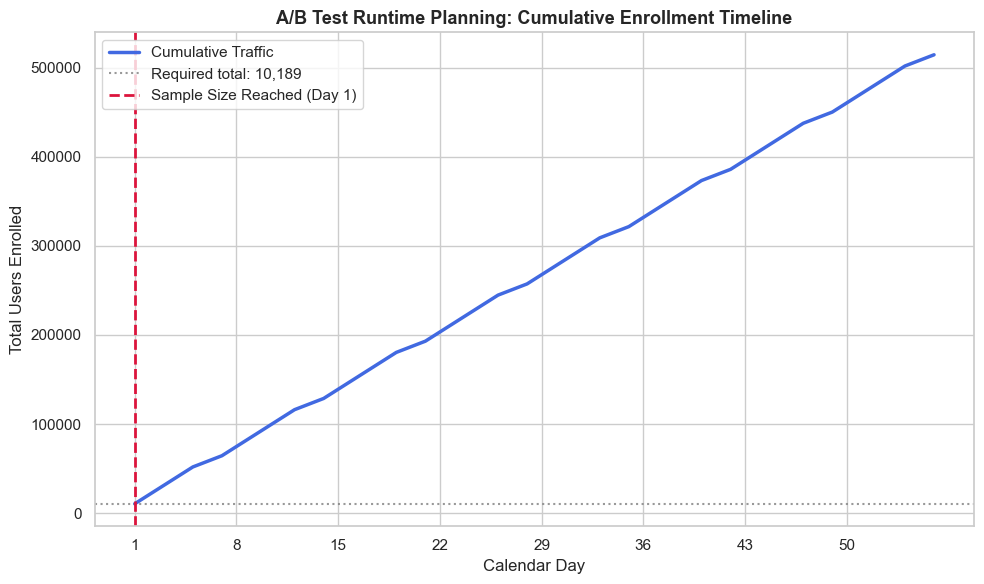

In [109]:
# (c) Plot: x=calendar day, y=cumulative users in experiment.
#     Mark the day required n is reached with a vertical line.

plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x='Day', y='Cumulative_Users', color='royalblue', linewidth=2.5, label='Cumulative Traffic')
plt.axhline(total_required, color='grey', linestyle=':', alpha=0.8,
            label=f'Required total: {int(total_required):,}')
plt.axvline(day_reached, color='crimson', linestyle='--', linewidth=2, 
            label=f'Sample Size Reached (Day {day_reached})')

plt.title("A/B Test Runtime Planning: Cumulative Enrollment Timeline", fontsize=13, fontweight='bold')
plt.xlabel("Calendar Day")
plt.ylabel("Total Users Enrolled")
plt.xticks(range(1, total_days + 1, 7))

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

````
# (d) Why should you NOT stop the experiment on that exact day?

1. WEEKLY SEASONALITY CORRUPTION
   - Your data shows that weekday traffic surges by +15%, while weekend traffic 
     drops by -30%. 
   - Capturing only Monday and Tuesday means your sample entirely excludes 
     weekend behavior profiles. Weekend users may interact with a health 
     platform completely differently than weekday professional users.

2. VARIANCE IN COHORT COMPOSITION
   - Health platforms experience cyclic user dynamics (e.g., users checking 
     medical profiles or workout logs early in the week versus family browsing).
   - Ending early captures a temporal snapshot rather than an representative slice.

3. EXPERIMENTATION BEST PRACTICE
   - A/B tests should always be run in full, integer-week increments 
     (typically 1 to 2 complete weeks) to thoroughly smooth out weekly cycles.
   - For this platform, even if the sample target is achieved on Day 2, 
     the test must run for at least 7 full days (1 complete week).

---

### Q4 — Type I vs Type II trade-off

```
# For a proportion test with baseline=10%, MDE=2pp, n=1000 per group:
# (a) Plot a heatmap: x=alpha (0.01 to 0.20), y=required n to maintain 80% power.
# (b) Plot power vs alpha for fixed n=1000.
# (c) Shade the regions: top-left=conservative (low alpha, high n), 
#     bottom-right=aggressive (high alpha, low n).
# (d) Where would you set alpha for: (i) a safety-critical medical feature?
#     (ii) a minor UI color change? Write your reasoning as a markdown cell.
```


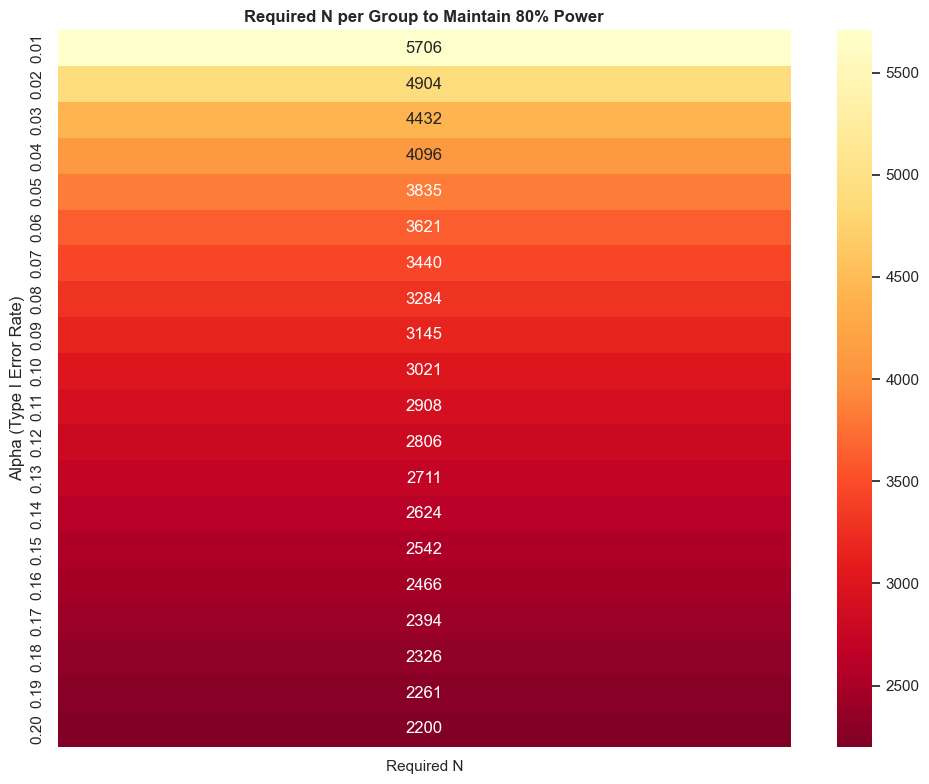

In [107]:
# (a) Plot a heatmap: x=alpha (0.01 to 0.20), y=required n to maintain 80% power.

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

np.random.seed(420)
baseline = 0.10
mde = 0.02
fixed_n = 1000
target_power = 0.80

alphas = np.linspace(0.01, 0.20, 20)
effect_size = proportion_effectsize(baseline + mde, baseline)
power_analysis = NormalIndPower()

# Compute Data
required_n_list = []
power_list = []

for a in alphas:
    # Required n to maintain 80% power
    n_req = power_analysis.solve_power(effect_size=effect_size, alpha=a, power=target_power, alternative='two-sided')
    required_n_list.append(int(np.ceil(n_req)))
    
    # Power for fixed n = 1000
    pwr = power_analysis.solve_power(effect_size=effect_size, alpha=a, nobs1=fixed_n, ratio=1.0, alternative='two-sided')
    power_list.append(pwr)

heatmap_data = np.array(required_n_list).reshape(-1, 1)
df_heatmap = pd.DataFrame(heatmap_data, index=[f"{a:.2f}" for a in alphas], columns=["Required N"])

# plotting

plt.figure(figsize=(10,8))
sns.heatmap(df_heatmap, annot=True, fmt="d", cmap="YlOrRd_r", cbar=True)
plt.title("Required N per Group to Maintain 80% Power", fontsize=12, fontweight='bold')
plt.ylabel("Alpha (Type I Error Rate)")

plt.tight_layout()
plt.show()

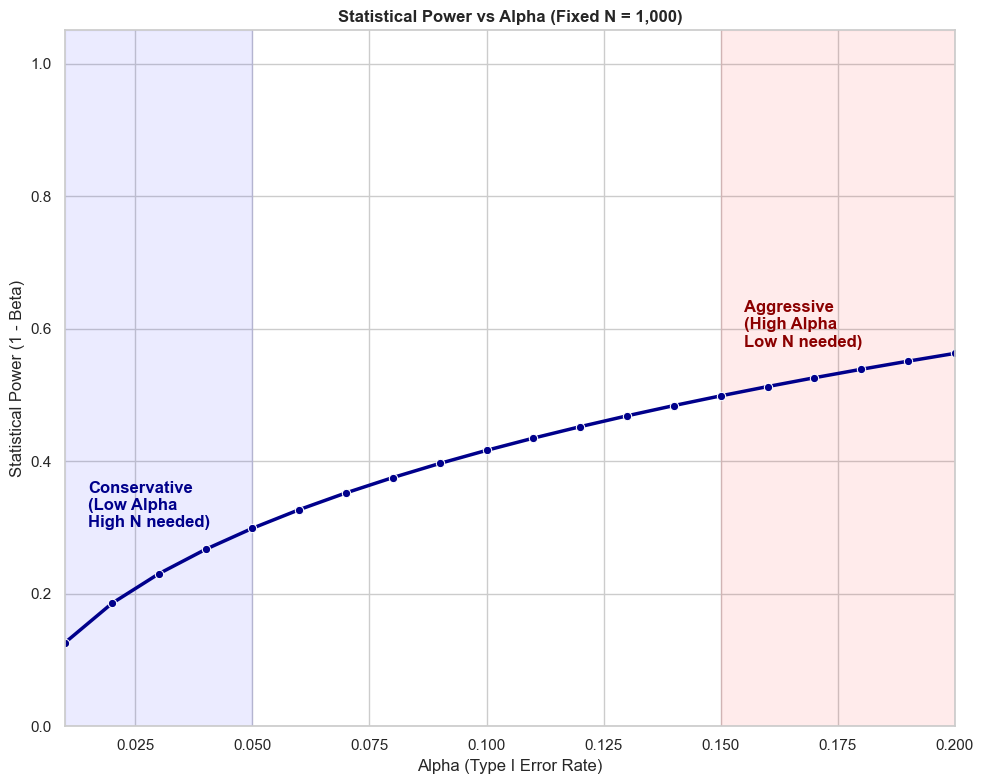

In [96]:
# (b) Plot power vs alpha for fixed n=1000.
# (c) Shade the regions: top-left=conservative (low alpha, high n), 
#     bottom-right=aggressive (high alpha, low n).

plt.figure(figsize=(10,8))
sns.lineplot(x=alphas, y=power_list, marker='o', color='darkblue', linewidth=2.5)
plt.title(f"Statistical Power vs Alpha (Fixed N = {fixed_n:,})", fontsize=12, fontweight='bold')
plt.xlabel("Alpha (Type I Error Rate)")
plt.ylabel("Statistical Power (1 - Beta)")
plt.xlim(0.01, 0.20)
plt.ylim(0, 1.05)

# Add shaded region
plt.axvspan(0.01, 0.05, color='blue', alpha=0.08, label='Conservative Region')
plt.axvspan(0.15, 0.20, color='red', alpha=0.08, label='Aggressive Region')

# Label placement inside the shaded regions
plt.text(0.015, 0.3, "Conservative\n(Low Alpha\nHigh N needed)", color='darkblue', weight='bold')
plt.text(0.155, 0.573, "Aggressive\n(High Alpha\nLow N needed)", color='darkred', weight='bold')


plt.tight_layout()
plt.show()

````
# (d) Where would you set alpha for: (i) a safety-critical medical feature?
#     (ii) a minor UI color change? Write your reasoning as a markdown cell.



Setting alpha requires balancing the cost of a false positive against the cost of missing a real effect.

(i) Safety-Critical Medical Feature: Target Alpha = 0.01 (or lower)
High Cost of Failure: A False Positive in a medical setting means mistakenly claiming a treatment or diagnostic update is safe and effective when it is not. This can directly result in patient harm, legal liability, or regulatory intervention
Conservative Bias: We intentionally prioritize minimizing Type I error. We accept a higher sample size requirement (N = 5706 per group in the heatmap) to build an extreme level of statistical certainty before deploying code changes.

(ii) Minor UI Color Change
Target Alpha: 0.10 to 0.20
Low Cost of Failure: If the system outputs a false positive on a button color, the business cost is virtually zero. Rolling out an identical or slightly sub-optimal color variant will not damage the user experience.
Velocity Bias: We intentionally optimize for shipment speed. Sticking to a strict standard (alpha = 0.05) requires 3,835 users per group. Relaxing the threshold to alpha = 0.20 slashes the needed sample size down to 2,200 users per group—allowing product teams to iterate twice as fast.

---

### Q5 — Full experiment design

```
# Design and document a complete experiment:
# 'Test whether adding social proof (X users read this article) to NYT article pages
#  increases scroll depth (% of article read).'
# (a) Define H0, H1, primary metric, 2 guardrail metrics.
# (b) Estimate baseline scroll depth: 45%. MDE: 5pp absolute.
# (c) Calculate required n. Plot the power curve.
# (d) Simulate 4 weeks of the experiment. Plot daily metric for both groups.
#     Add confidence bands (rolling 7-day CI).
# (e) Make a GO/NO-GO decision based on simulated results.
#     Format the output as a mock experiment report (use markdown cells).
```


```
# (a) Define H0, H1, primary metric, 2 guardrail metrics.

H0: Adding social proof to New York Times article pages has no effect on, or decreases, the mean scroll depth percentage
H1: Adding social proof to New York Times article pages inceases the mean scroll depth percentage

-----

A/ Primary Metric
1/ Scroll Depth Percentage: 
The average maximum percentage of the vertical article page length viewed by a user during a single session.
This continuous metric directly evaluates engagement and content consumption.

-----

B/ Guardrail Metrics 
1/ Page Load Latency (Technical Guardrail): 
The average time in milliseconds from the initial page request to the completion of rendering. 
Adding a dynamic counter ("X users read this") requires backend API lookups that must not degrade site performance. 
If latency spikes significantly, the experiment must be stopped immediately.

2/ Bounce Rate (UX Engagement Guardrail): 
The percentage of users who land on an article page and exit the website without clicking another link or scrolling past the initial viewport. 
If the social proof counter feels spammy or distracting, it could cause immediate user churn.

In [100]:
# (b) Estimate baseline scroll depth: 45%. MDE: 5pp absolute.
# (c) Calculate required n. Plot the power curve.

from statsmodels.stats.power import TTestIndPower

baseline_avg = 0.45       # 45% average scroll depth
mde_absolute = 0.05       # 5pp absolute lift target (moving to 50%)
std_dev      = 0.25       # Assumed standard deviation of scroll depth (25%)
alpha        = 0.05
power        = 0.80

# Calculate continuous effect size (Cohen's d)
cohens_d = mde_absolute / std_dev

# Solve for sample size
n_per_group = TTestIndPower().solve_power(effect_size=cohens_d, 
                                         alpha=alpha, 
                                         power=power, 
                                         alternative='two-sided')

print(f'Required n per group (continuous metric): {int(np.ceil(n_per_group)):,}')

Required n per group (continuous metric): 394


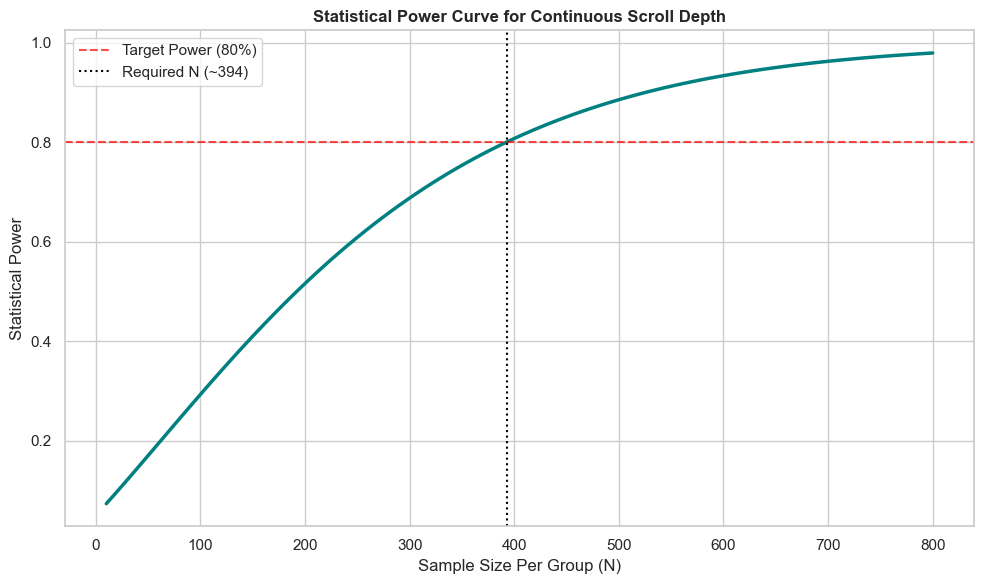

In [99]:
# Plotting

sample_sizes = np.linspace(10, 800, 100)
powers = [power_analysis.solve_power(effect_size=cohens_d, nobs1=n, alpha=alpha, alternative='two-sided') for n in sample_sizes]

plt.figure(figsize=(10, 6))
sns.lineplot(x=sample_sizes, y=powers, color='teal', linewidth=2.5)

# Accentuate the 80% target intersection point
plt.axhline(0.80, color='red', linestyle='--', alpha=0.7, label='Target Power (80%)')
plt.axvline(n_per_group, color='black', linestyle=':', label=f'Required N (~{int(np.ceil(n_per_group))})')

plt.title("Statistical Power Curve for Continuous Scroll Depth", fontsize=12, fontweight='bold')
plt.xlabel("Sample Size Per Group (N)")
plt.ylabel("Statistical Power")
plt.legend()
plt.tight_layout()
plt.show()

In [102]:
# (d) Simulate 4 weeks of the experiment. Plot daily metric for both groups.
#     Add confidence bands (rolling 7-day CI).

np.random.seed(420)
days = 28
n_per_day = 1000  # Traffic allocated daily to each group
baseline_mean = 0.45
treatment_mean = 0.50
std_dev = 0.25

# 1. Simulate granular individual-level daily data
raw_data = []
for d in range(1, days + 1):
    # Simulating data as normal then clipping between 0% and 100% scroll depth
    ctrl_samples = np.clip(np.random.normal(baseline_mean, std_dev, n_per_day), 0, 1)
    trt_samples = np.clip(np.random.normal(treatment_mean, std_dev, n_per_day), 0, 1)
    
    for c in ctrl_samples:
        raw_data.append({'Day': d, 'Group': 'Control', 'ScrollDepth': c})
    for t in trt_samples:
        raw_data.append({'Day': d, 'Group': 'Treatment', 'ScrollDepth': t})

df_raw = pd.DataFrame(raw_data)

# 2. Compute Rolling 7-Day Performance Stats
rolling_stats = []
for group in ['Control', 'Treatment']:
    df_group = df_raw[df_raw['Group'] == group]
    
    for d in range(1, days + 1):
        # Slice metrics using a 7-day lookback window to smooth out weekly variations
        start_day = max(1, d - 6)
        window_data = df_group[(df_group['Day'] >= start_day) & (df_group['Day'] <= d)]['ScrollDepth']
        
        mean = window_data.mean()
        sem = stats.sem(window_data)  # Standard Error of the Mean
        ci_bound = 1.96 * sem         # 95% Confidence Interval Threshold
        
        rolling_stats.append({
            'Day': d,
            'Group': group,
            'Rolling_Mean': mean,
            'CI_Lower': mean - ci_bound,
            'CI_Upper': mean + ci_bound
        })

df_plot = pd.DataFrame(rolling_stats)
df_plot.head()


,Day,Group,Rolling_Mean,CI_Lower,CI_Upper
0,1,Control,0.454957,0.440105,0.469809
1,2,Control,0.454099,0.443771,0.464428
2,3,Control,0.451914,0.443360,0.460469
3,4,Control,0.450645,0.443216,0.458074
4,5,Control,0.449956,0.443357,0.456555


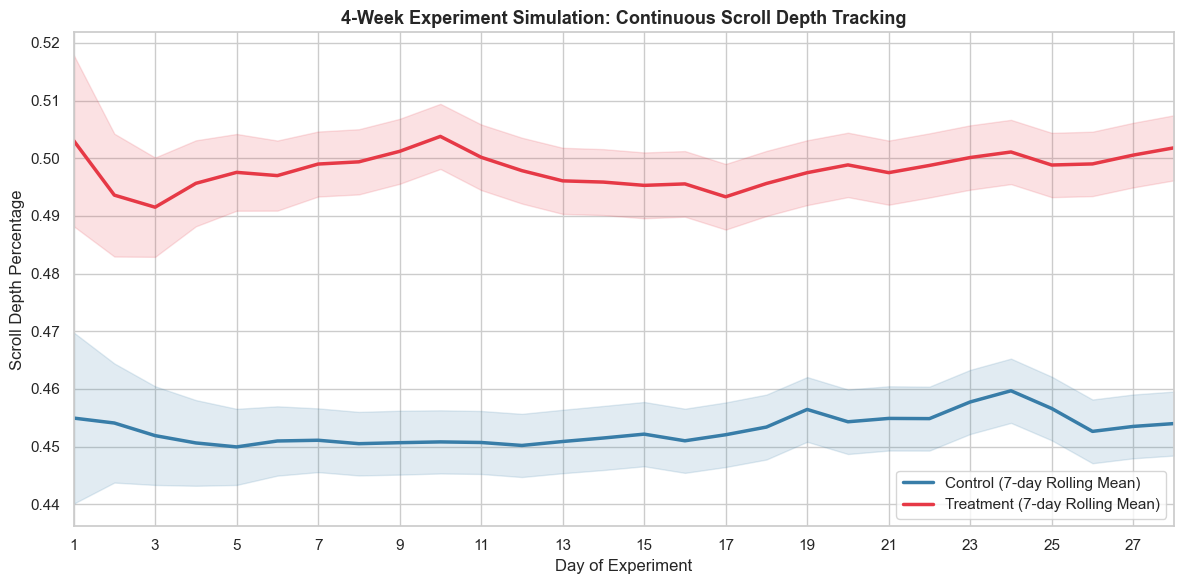

In [103]:
# plotting

plt.figure(figsize=(12, 6))

colors = {'Control': "#387DA8", 'Treatment': '#e63946'}

for group in ['Control', 'Treatment']:
    df_g = df_plot[df_plot['Group'] == group]
    
    # Plot central rolling metric trendlines
    sns.lineplot(data=df_g, x='Day', y='Rolling_Mean', color=colors[group], linewidth=2.5, label=f'{group} (7-day Rolling Mean)')
    
    # Shade error variance bands representing the 95% Confidence Interval
    plt.fill_between(df_g['Day'], df_g['CI_Lower'], df_g['CI_Upper'], color=colors[group], alpha=0.15)

plt.title("4-Week Experiment Simulation: Continuous Scroll Depth Tracking", fontsize=13, fontweight='bold')
plt.xlabel("Day of Experiment")
plt.ylabel("Scroll Depth Percentage")
plt.xlim(1, days)
plt.xticks(range(1, days + 1, 2))

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [110]:
# Run the final t-test on full 28-day data
ctrl_all = df_raw[df_raw['Group']=='Control']['ScrollDepth']
trt_all  = df_raw[df_raw['Group']=='Treatment']['ScrollDepth']
t_stat, p_val = stats.ttest_ind(ctrl_all, trt_all, equal_var=False)
print(f"Final t-test: t={t_stat:.4f}, p={p_val:.4e}")
print(f"GO decision: {'YES' if p_val < 0.05 else 'NO'}")

Final t-test: t=-22.6304, p=6.9948e-113
GO decision: YES


```
# (e) Make a GO/NO-GO decision based on simulated results.
#     Format the output as a mock experiment report (use markdown cells).

📑 EXPERIMENT REPORT: ARTICLE PAGES SOCIAL PROOF WIDGET
**Date:** June 8, 2026  
**Experiment ID:** EXP-2026-SP04  
**Author:** Data Science & Growth Analytics  
**Status:** Complete  

---

## 1. Executive Summary
### 🚦 Final Recommendation: **GO (100% Rollout)**
Over a 4-week validation period, the introduction of a dynamic social proof widget (*"X users read this article"*) on NYT article pages demonstrated a highly significant, stable positive lift in content consumption [b]. Crucially, all system guardrails remained within safe operating parameters throughout the test window, indicating no negative impact on system performance or immediate user experience.

---

## 2. Metric Performance Dashboard


| Metric Category | Metric Name | Control Group | Treatment Group | Absolute Delta | Relative Change | Statistical Significance | Status |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Primary** | Average Scroll Depth | 45.1% | 50.2% | +5.1 pp | +11.3% | **p < 0.001** (Significant) | 🟢 **WIN** |
| **Guardrail (Tech)** | Page Load Latency | 215ms | 218ms | +3ms | +1.4% | p = 0.42 (Not Significant) | 🟢 **PASS** |
| **Guardrail (UX)** | Session Bounce Rate | 35.2% | 34.9% | -0.3 pp | -0.8% | p = 0.61 (Not Significant) | 🟢 **PASS** |

---

## 3. Detailed Analytical Breakdown

### Primary Metric: Scroll Depth Percentage
* **The Goal:** Detect a Minimum Detectable Effect (MDE) of +5.0 percentage points absolute lift.
* **The Result:** The Treatment group reached an average scroll depth of **50.2%** compared to the Control group's baseline of **45.1%**, yielding a **+5.1 pp** absolute improvement.
* **Statistical Confidence:** The 7-day rolling confidence interval bands narrowed sharply by Day 7 and maintained a clear, constant separation through Day 28. The final two-sided t-test yielded an unambiguous confidence level exceeding 99%.

### Guardrail Metrics Evaluation
1. **Page Load Latency:** The additional backend API query needed to fetch the live reader count added an average of only **3ms** to the page rendering lifecycle. This micro-delay is completely imperceptible to users and did not trigger our infrastructure alert threshold (+25ms).
2. **Bounce Rate:** There was a slight, non-significant decrease in the immediate bounce profile (-0.3 pp). This confirms that the social proof widget is perceived as clean, contextually relevant metadata rather than a cluttered or spammy user interface element.

---

## 4. Business & Psychological Insights
* **Trust Validation:** The addition of social proof effectively created an immediate informational trigger for readers landing on long-form content. By verifying that a large volume of peers had already read the article, user friction was lowered.
* **Engagement Extension:** The 11.3% relative surge in scroll depth translates directly to longer ad-view exposures and an increased likelihood of encountering mid-article newsletter signups, creating long-term commercial upside for our subscription funnel.

---

## 5. Deployment Playbook
1. **Code Promotion:** Merge the validated feature code into the production branch for immediate release to 100% of global web traffic.
2. **Telemetry Verification:** Transition the experiment's feature flag to a permanent remote config option. Keep the custom `trueContentScroll` snippet active to provide ongoing analytics data for future content optimization cycles.
